In [1]:
import pandas as pd
from pymongo import MongoClient

import matplotlib.pyplot as plt
from datetime import datetime

import numpy as np

In [2]:
DB = "amlsim100"
DATASET = "datasets/AMLSimData/0_100"

In [3]:
# Set connection
client = MongoClient("mongodb://localhost:27017/")
db = client["bank"]
balances_collection = db[DB]

# Load csv
accounts = pd.read_csv(f'{DATASET}/accounts.csv')
transactions = pd.read_csv(f'{DATASET}/transactions.csv')

In [4]:
# Create root
balances = {}

# Take users data from account.csv
for _, row in accounts.iterrows():
    acc_id = row["ACCOUNT_ID"] # User id
    open_date = 0
    initial_balance = round(float(row["INIT_BALANCE"]), 2)

    balances[acc_id] = [{"date": open_date,
                         "balance": initial_balance
                        }]
    
    if acc_id == 0: # Check
        print("first user must be 0 => ",str(acc_id))
        print("user 0 initial deposit must be 184.44 => ", initial_balance)

first user must be 0 =>  0
user 0 initial deposit must be 184.44 =>  184.44


In [5]:
print(len(transactions))

17144


In [6]:
balances[0][0]

{'date': 0, 'balance': 184.44}

In [7]:
# Apply transactions to users' balances
transactions.sort_values(by="TX_ID")

# Track the last balance for each account
current_balances = {acct_id: balances[acct_id][0]["balance"] for acct_id in balances}

for i, (_, row) in enumerate(transactions.iterrows()):
    orig_acct = row["SENDER_ACCOUNT_ID"]
    bene_acct = row["RECEIVER_ACCOUNT_ID"]
    amount = row["TX_AMOUNT"]
    tx_type = row['TX_TYPE']
    date = row["TIMESTAMP"]

    # if i == 0:
    #     print("first transaction must be from 6456 to 9069 => ", orig_acct, bene_acct)
    # if i == 1323233: # check that read till the last transaction
    #     print("\nlast transaction must be from 545 to 2724 => ", orig_acct, bene_acct)

    if orig_acct in balances: # check that sender has a deposit
        last_balance = balances[orig_acct][-1]["balance"] # read balance from balances
        if tx_type in ['TRANSFER', 'WITHDRAWAL']: # all TRANSFER in the csv
            new_balance = last_balance - amount
        # elif tx_type == 'DEPOSIT':
        #    new_balance = last_balance + amount

        balances[orig_acct].append({"date": date, "balance": round(new_balance, 2)})
        if orig_acct == 1 and date == 1:
            print()
            print(row['TX_ID'])
            print(f"on date {date} user {orig_acct} send to {bene_acct} {amount} dollars")
            print(f"user {orig_acct} balance goes from {last_balance} to {new_balance}")
            print(balances[orig_acct])
            
    
    if bene_acct in balances: # check that receiver has a deposit
        last_balance = balances[bene_acct][-1]["balance"]
        if tx_type in ['TRANSFER', 'DEPOSIT']:
            new_balance = last_balance + amount
        # elif tx_type == 'WITHDRAWAL':
        #     new_balance = last_balance - amount

        balances[bene_acct].append({"date": date, "balance": round(new_balance, 2)})
        if bene_acct == 0:
            print()
            print(row['TX_ID'])
            print(f"on date {date} user {orig_acct} send to {bene_acct} {amount} dollars")
            print(f"user {bene_acct} balance goes from {last_balance} to {new_balance}")
            print(balances[bene_acct])
            


62
on date 1 user 1 send to 48 58.6 dollars
user 1 balance goes from 175.8 to 117.20000000000002
[{'date': 0, 'balance': 175.8}, {'date': 1, 'balance': 117.2}]

63
on date 1 user 1 send to 50 58.6 dollars
user 1 balance goes from 117.2 to 58.6
[{'date': 0, 'balance': 175.8}, {'date': 1, 'balance': 117.2}, {'date': 1, 'balance': 58.6}]

64
on date 1 user 1 send to 61 58.6 dollars
user 1 balance goes from 58.6 to 0.0
[{'date': 0, 'balance': 175.8}, {'date': 1, 'balance': 117.2}, {'date': 1, 'balance': 58.6}, {'date': 1, 'balance': 0.0}]

86
on date 2 user 21 send to 0 69.19 dollars
user 0 balance goes from 184.44 to 253.63
[{'date': 0, 'balance': 184.44}, {'date': 2, 'balance': 253.63}]

189
on date 3 user 21 send to 0 69.19 dollars
user 0 balance goes from 253.63 to 322.82
[{'date': 0, 'balance': 184.44}, {'date': 2, 'balance': 253.63}, {'date': 3, 'balance': 322.82}]

568
on date 7 user 53 send to 0 51.55 dollars
user 0 balance goes from 322.82 to 374.37
[{'date': 0, 'balance': 184.44

In [8]:
balances[0]

[{'date': 0, 'balance': 184.44},
 {'date': 2, 'balance': 253.63},
 {'date': 3, 'balance': 322.82},
 {'date': 7, 'balance': 374.37},
 {'date': 13, 'balance': 443.56},
 {'date': 16, 'balance': 351.34},
 {'date': 16, 'balance': 259.12},
 {'date': 18, 'balance': 310.67},
 {'date': 23, 'balance': 379.86},
 {'date': 26, 'balance': 287.64},
 {'date': 26, 'balance': 195.42},
 {'date': 27, 'balance': 103.2},
 {'date': 27, 'balance': 10.98},
 {'date': 27, 'balance': 62.53},
 {'date': 29, 'balance': -29.69},
 {'date': 29, 'balance': -121.91},
 {'date': 30, 'balance': -52.72},
 {'date': 31, 'balance': 16.47},
 {'date': 37, 'balance': -75.75},
 {'date': 37, 'balance': -167.97},
 {'date': 38, 'balance': -116.42},
 {'date': 49, 'balance': -47.23},
 {'date': 49, 'balance': -139.45},
 {'date': 49, 'balance': -231.67},
 {'date': 51, 'balance': -162.48},
 {'date': 53, 'balance': -93.29},
 {'date': 57, 'balance': -185.51},
 {'date': 57, 'balance': -277.73},
 {'date': 58, 'balance': -226.18},
 {'date': 68,

In [9]:
len(balances)

100

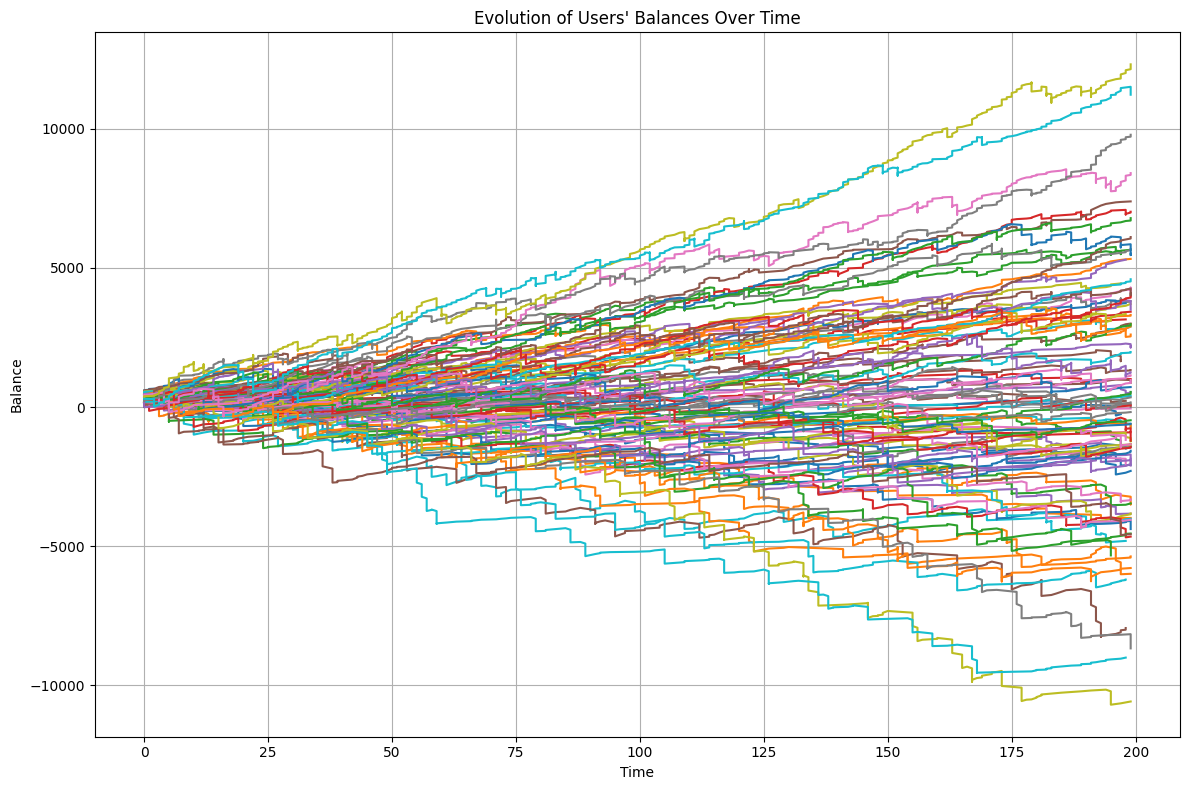

In [10]:
# Plot the balance evolution for each account
plt.figure(figsize=(12, 8))
for acct_id, account_data in balances.items():
    dates = [entry["date"] for entry in account_data]
    balance_values = [entry["balance"] for entry in account_data]
    plt.plot(dates, balance_values, label=f'Account {acct_id}')

plt.title('Evolution of Users\' Balances Over Time')
plt.xlabel('Time')
plt.ylabel('Balance')
plt.grid(True)
plt.tight_layout()
plt.show()

In [11]:
for i, (acct_id, account_data) in enumerate(balances.items()):
    if i < 2:
        print(acct_id)
        print(account_data)    

0
[{'date': 0, 'balance': 184.44}, {'date': 2, 'balance': 253.63}, {'date': 3, 'balance': 322.82}, {'date': 7, 'balance': 374.37}, {'date': 13, 'balance': 443.56}, {'date': 16, 'balance': 351.34}, {'date': 16, 'balance': 259.12}, {'date': 18, 'balance': 310.67}, {'date': 23, 'balance': 379.86}, {'date': 26, 'balance': 287.64}, {'date': 26, 'balance': 195.42}, {'date': 27, 'balance': 103.2}, {'date': 27, 'balance': 10.98}, {'date': 27, 'balance': 62.53}, {'date': 29, 'balance': -29.69}, {'date': 29, 'balance': -121.91}, {'date': 30, 'balance': -52.72}, {'date': 31, 'balance': 16.47}, {'date': 37, 'balance': -75.75}, {'date': 37, 'balance': -167.97}, {'date': 38, 'balance': -116.42}, {'date': 49, 'balance': -47.23}, {'date': 49, 'balance': -139.45}, {'date': 49, 'balance': -231.67}, {'date': 51, 'balance': -162.48}, {'date': 53, 'balance': -93.29}, {'date': 57, 'balance': -185.51}, {'date': 57, 'balance': -277.73}, {'date': 58, 'balance': -226.18}, {'date': 68, 'balance': -318.4}, {'date

In [12]:
def is_monotonic(balance_values):
    return np.all(np.diff(balance_values) >= 0) or np.all(np.diff(balance_values) <= 0)

monotonic_accounts = []
non_monotonic_accounts = []

for acct_id, account_data in balances.items():
    account_data = sorted(account_data, key=lambda x: x["date"])  # sort by date (even they are sorted yet)
    # account_data is an array with [{date, balance} for each day for each user]

    balance_values = [entry["balance"] for entry in account_data]
    
    if is_monotonic(balance_values):
        monotonic_accounts.append(acct_id)
    else:
        non_monotonic_accounts.append(acct_id)

print(f"Monotonic Account: {len(monotonic_accounts)}")
print(f"Non Monotonic Account: {len(non_monotonic_accounts)}")
print(f"Percentage of monotonic account: {round(((len(monotonic_accounts) / len(balances)) * 100),2)}%")

assert len(balances) == (len(monotonic_accounts) + len(non_monotonic_accounts))

Monotonic Account: 0
Non Monotonic Account: 100
Percentage of monotonic account: 0.0%


In [13]:
# Send the data to DB

result = []

for date in sorted(set(transactions["TIMESTAMP"])):
    daily_balances = {
        "date": date,
        "balances": {
            str(user): {
                "balance": next((entry["balance"] for entry in reversed(b) if entry["date"] <= date), b[0]["balance"])
            } for user, b in balances.items()}
    }
    result.append(daily_balances)
    balances_collection.insert_one(daily_balances)

print("All balances are now updated in the DB")

All balances are now updated in the DB


In [14]:
df = pd.DataFrame(result)

In [16]:
# Unpack 'balances' into separate columns for each user
df = df.join(pd.DataFrame(df['balances'].tolist()))

# Drop the now redundant 'balances' column and set 'date' as index
df.drop('balances', axis=1, inplace=True)
df.set_index('date', inplace=True)

print(df)

                           _id                      0                      1  \
date                                                                           
0     67d56074afd1e1c6bffb9c6d    {'balance': 184.44}     {'balance': 175.8}   
1     67d56074afd1e1c6bffb9c6e    {'balance': 184.44}       {'balance': 0.0}   
2     67d56074afd1e1c6bffb9c6f    {'balance': 253.63}     {'balance': 12.38}   
3     67d56074afd1e1c6bffb9c70    {'balance': 322.82}     {'balance': 12.38}   
4     67d56074afd1e1c6bffb9c71    {'balance': 322.82}     {'balance': 22.28}   
...                        ...                    ...                    ...   
195   67d56075afd1e1c6bffb9d30  {'balance': -1312.03}  {'balance': -3998.92}   
196   67d56075afd1e1c6bffb9d31  {'balance': -1312.03}  {'balance': -3998.92}   
197   67d56075afd1e1c6bffb9d32  {'balance': -1312.03}  {'balance': -3998.92}   
198   67d56075afd1e1c6bffb9d33  {'balance': -1496.47}  {'balance': -3998.92}   
199   67d56075afd1e1c6bffb9d34  {'balanc

In [18]:
# Remove the '_id' column
df.drop('_id', axis=1, inplace=True, errors='ignore')

# Extract the 'balance' values from the dictionary entries
for col in df.columns:
    df[col] = df[col].apply(lambda x: x['balance'] if isinstance(x, dict) else x)

df

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
date,,,,,,,,,,,,,,,,,,,,,
0,184.44,175.80,142.06,125.89,151.13,140.49,178.38,130.33,147.66,158.34,...,411.76,331.00,340.34,426.02,463.36,411.81,437.84,238.28,386.67,297.29
1,184.44,0.00,142.06,125.89,182.79,140.49,194.34,130.33,163.62,31.70,...,411.76,346.06,356.30,426.02,463.36,411.81,452.90,238.28,386.67,297.29
2,253.63,12.38,142.06,138.27,195.17,217.43,194.34,130.33,163.62,92.89,...,485.33,425.57,356.30,426.02,475.74,578.08,452.90,307.47,416.62,12.55
3,322.82,12.38,142.06,138.27,195.17,217.43,264.42,164.84,163.62,92.89,...,517.69,425.57,356.30,461.13,475.74,647.27,452.90,406.85,551.40,147.33
4,322.82,22.28,198.79,138.27,283.92,76.94,264.42,202.88,163.62,92.89,...,758.87,493.80,137.97,478.19,592.32,702.29,165.99,637.58,681.07,272.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,-1312.03,-3998.92,-1015.09,-929.73,759.18,175.20,-68.40,131.37,-953.47,-445.13,...,6129.84,2741.40,6605.25,3671.52,1318.73,5914.94,7758.35,9444.49,11741.15,11217.91
196,-1312.03,-3998.92,-1157.14,-929.73,759.18,175.20,-68.40,131.37,-953.47,-445.13,...,6129.84,2754.61,6605.25,3709.68,1318.73,5932.86,7897.52,9457.70,11788.50,11285.84
197,-1312.03,-3998.92,-1299.19,-929.73,639.73,175.20,-68.40,131.37,-953.47,-571.77,...,5823.71,2800.86,6641.93,3833.55,1418.36,5990.27,8095.31,9607.42,11959.72,11468.65
